# 🚖 Prédiction du Tarif des Taxis à New York City
## Notebook 2 : Modélisation et Évaluation des Modèles

---

### 📋 Prérequis

Ce notebook est la **deuxième partie** du projet.  
Il suppose que le **Notebook 1 — Nettoyage et Préparation des Données** a été exécuté avec succès et que le DataFrame `data_wsh` est disponible en mémoire (ou rechargé depuis le fichier exporté).

---

### 🎯 Objectif

Entraîner, évaluer et comparer plusieurs modèles de régression pour prédire le montant du tarif de taxi (`fare_amount`), et sauvegarder les meilleurs modèles pour une utilisation en production.

---

### 🗂️ Structure de ce notebook

| Étape | Description |
|-------|-------------|
| **1. Imports & Configuration** | Chargement des bibliothèques de modélisation |
| **2. Préparation des matrices X / y** | Séparation variables explicatives / cible |
| **3. Séparation Train / Test** | Division stratifiée 70% / 30% |
|
| **5. Fonctions utilitaires** | Fonctions d'entraînement et d'évaluation réutilisables |
| **6. Régression Linéaire** | Baseline linéaire + diagnostics statistiques (résidus, VIF, normalité) |
| **7. Régression Ridge** | Modèle linéaire régularisé + optimisation des hyperparamètres |
| **8. Validation Croisée** | Évaluation robuste de la régression linéaire par cross-validation |
| **9. Importance des variables** | Analyse des coefficients de la régression linéaire |
| **10. Arbre de Décision** | Modèle non linéaire + GridSearchCV |
| **11. LightGBM** | Modèle de gradient boosting + GridSearchCV |
| **12. Sauvegarde des modèles** | Sérialisation des meilleurs modèles avec joblib |

---

> 💡 **Métriques d'évaluation utilisées :** MAE, MAPE, RMSE, R²


---
## ⚙️ Section 1 — Imports & Configuration

Nous importons ici l'ensemble des bibliothèques nécessaires à la modélisation :
- **scikit-learn** — modèles ML, métriques, validation croisée, preprocessing
- **statsmodels** — régression OLS pour les tests statistiques
- **lightgbm** — gradient boosting optimisé
- **yellowbrick** — visualisation des résidus
- **joblib** — sérialisation des modèles

> ⚠️ Ce notebook nécessite également que les bibliothèques de visualisation (`matplotlib`, `seaborn`, `pandas`, `numpy`) soient disponibles.


# Modeling

In [12]:
from sklearn import linear_model
import pandas as pd
import statsmodels.formula.api as smf
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.diagnostic import het_white , normal_ad

---
## 🔀 Section 2 — Préparation des matrices X et y

Nous séparons le DataFrame `data_wsh` en :
- **X** — matrice des variables explicatives (toutes les colonnes sauf `fare_amount`)
- **y** — vecteur cible (`fare_amount` en USD)

Avant la séparation, nous trions le dataset par année de prise en charge (`pickup_year`) pour respecter l'ordre temporel des observations.


In [2]:
import joblib
data_wsh =joblib.load('/kaggle/input/datasets/machinelearningk/data-wsh/ma_variable.pkl')

In [3]:
data_wsh=data_wsh.sort_values(by='pickup_year')

In [4]:
# Création des variables explicatives et cible:
# X est la liste des variables explicatives et y est la variable cible
X = data_wsh.drop(["fare_amount"],axis=1)  # ou data.drop(["margin_low", "is_genuine"], axis=1)
y = data_wsh.loc[:,["fare_amount"]]

In [156]:
y.describe()

,fare_amount
count,1.917887e+06
mean,1.292110e+01
std,1.100874e+01
min,2.500000e+00
25%,6.500000e+00
50%,9.500000e+00
75%,1.450000e+01
max,9.520000e+02


---
## ✂️ Section 3 — Séparation Train / Test

Nous divisons les données en un **jeu d'entraînement (70%)** et un **jeu de test (30%)**.

**Principes appliqués :**
- `random_state=42` pour la reproductibilité



### 3.1 Inspection des variables avant la séparation


## Train / Test split

In [157]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1917887 entries, 10191011 to 1984093
Data columns (total 22 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   passenger_count                int8   
 1   pickup_hour                    int8   
 2   pickup_month                   int8   
 3   pickup_year                    int16  
 4   pickup_day_of_week             int8   
 5   distance_km                    float32
 6   is_pickup_JFK                  int64  
 7   is_dropoff_JFK                 int64  
 8   is_pickup_EWR                  int64  
 9   is_dropoff_EWR                 int64  
 10  is_pickup_la_guardia           int64  
 11  is_dropoff_la_guardia          int64  
 12  pickup_borough_brooklyn        int64  
 13  pickup_borough_manhattan       int64  
 14  pickup_borough_others          int64  
 15  pickup_borough_queens          int64  
 16  pickup_borough_staten_island   int64  
 17  dropoff_borough_brooklyn       int64  
 18  

In [5]:
# Séparons nos données en un jeu d'entraînement et un jeu de test :
# 30% des données dans le jeu de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Train set - X: {X_train.shape} ; y: {y_train.shape} \nTest set - X: {X_test.shape} ; y: {y_test.shape}")

Train set - X: (1342520, 22) ; y: (1342520, 1) 
Test set - X: (575367, 22) ; y: (575367, 1)


---
## 🔧 Section 5 — Fonctions utilitaires d'entraînement et d'évaluation

Nous définissons deux fonctions réutilisables pour standardiser l'entraînement et l'évaluation de tous nos modèles.

### `train_model`
Entraîne le modèle et affiche les métriques complètes (train + test) :
- **MAE** (Mean Absolute Error) — erreur absolue moyenne en USD
- **MAPE** (Mean Absolute Percentage Error) — erreur relative en %
- **RMSE** (Root Mean Squared Error) — pénalise davantage les grandes erreurs
- **R²** (Coefficient de détermination) — part de variance expliquée

### `train_model2`
Entraîne le modèle et retourne les prédictions brutes pour des analyses ultérieures (graphiques, diagnostics).


## Définition d'une fonction d'entrainement

In [6]:
def train_model(model, x_train, y_train, x_test, y_test):
    # On entraîne ce modèle sur les données d'entrainement
    model.fit(x_train,y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # On récupère l'erreur de norme 2 sur le jeu de données train
    mae_train = metrics.mean_absolute_error(y_train, y_train_pred)
    mape_train = metrics.mean_absolute_percentage_error(y_train, y_train_pred)
    rmse_train = metrics.root_mean_squared_error(y_train, y_train_pred)
    r2_train =  metrics.r2_score(y_train, y_train_pred)

    # jeu de données test
    mae_test = metrics.mean_absolute_error(y_test, y_test_pred)
    mape_test = metrics.mean_absolute_percentage_error(y_test, y_test_pred)
    rmse_test = metrics.root_mean_squared_error(y_test, y_test_pred)
    r2_test = metrics.r2_score(y_test, y_test_pred)

    # On obtient l'erreur MAE ci-dessous
    print(f"Model MAE test: {round(mae_test, 5)} \nMAPE: {round(100 * mape_test, 1)}%")
    return {"model": model,
            "mae_train": mae_train,
            "mape_train": mape_train,
            "rmse_train": rmse_train,
            "r2_train": r2_train,
            "mae_test": mae_test,
            "mape_test": mape_test,
            "rmse_test": rmse_test,
            "r2_test": r2_test,
           }


In [7]:
def train_model2(model, x_train, y_train, x_test, y_test):
    # On entraîne ce modèle sur les données d'entrainement
    model.fit(x_train,y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    return (y_train_pred,y_test_pred)

---
## 📈 Section 6 — Régression Linéaire (Baseline)

### 6.1 Entraînement du modèle

La **régression linéaire ordinaire (OLS)** constitue notre modèle de référence (*baseline*).  
Elle suppose une relation linéaire entre les variables explicatives et le tarif, ce qui nous permettra de vérifier par la suite si des modèles plus complexes apportent une amélioration significative.




In [8]:
lr = linear_model.LinearRegression(fit_intercept=False)

train_model(lr,X_train,y_train,X_test,y_test)

Model MAE test: 2.2597 
MAPE: 20.1%


{'model': LinearRegression(fit_intercept=False),
 'mae_train': 2.2605846874004945,
 'mape_train': 0.2014295516204373,
 'rmse_train': 4.031835138497857,
 'r2_train': 0.8656698453789888,
 'mae_test': 2.259697833435278,
 'mape_test': 0.2009686977223117,
 'rmse_test': 4.0423580896320885,
 'r2_test': 0.8656315246914709}

In [9]:
result=train_model2(lr,X_train,y_train,X_test,y_test)

In [10]:
y_train_pred = result[0]
y_test_pred= result[1]

### 6.2 Tests d'hypothèses statistiques

Pour valider la fiabilité de la régression linéaire, nous effectuons les tests statistiques classiques sur les résidus du modèle OLS estimé via `statsmodels`.


### Test d'hypothèses

In [13]:
train_complet = pd.concat([X_train, y_train], axis=1)
test_complet = pd.concat([X_test, y_test], axis=1)

# 2. On empile les lignes du Train et du Test pour recréer le dataset initial
dataset_reconstruit = pd.concat([train_complet, test_complet], axis=0)


formula = "fare_amount ~ " + " + ".join(X_train.columns)

reg_lin = smf.ols(formula=formula, data=dataset_reconstruit, axis=1).fit()
reg_lin.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['axis']
  warnings.warn(msg, ValueWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                 5.623e+05
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:39:24   Log-Likelihood:            -5.3960e+06
No. Observations:             1917887   AIC:                         1.079e+07
Df Residuals:                 1917864   BIC:                         1.079e+07
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                      -545.6584     13.821    -39.481      0.000    -572.747    -518.570
passenger_count                   0.0327      0.002     15.186      0.000       0.029       0.037
pickup_hour                       0.0180      0.000     39.951      0.000       0.017       0.019
pickup_month                      0.0501      0.001     51.513      0.000       0.048       0.052
pickup_year                       0.2717      0.007     39.614      0.000       0.258       0.285
pickup_day_of_week               -0.0688      0.001    -46.004      0.000      -0.072      -0.066
distance_km                       2.4314      0.001   1982.191      0.000       2.429       2.434
is_pickup_JFK                     0.2164      0.053      4.054      0.000       0.112       0.321
is_dropoff_JFK                    2.0691      0.042     49.675      0.000       1.987       2.151
is_pickup_EWR                    34.8607      1.177     29.617      0.000      32.554      37.168
is_dropoff_EWR                    7.5473      0.125     60.366      0.000       7.302       7.792
is_pickup_la_guardia              5.5258      0.051    108.970      0.000       5.426       5.625
is_dropoff_la_guardia             7.5401      0.034    224.755      0.000       7.474       7.606
pickup_borough_brooklyn          -0.5225      0.201     -2.602      0.009      -0.916      -0.129
pickup_borough_manhattan         -0.1906      0.195     -0.976      0.329      -0.573       0.192
pickup_borough_others           -10.1486      0.415    -24.463      0.000     -10.962      -9.335
pickup_borough_queens             0.8980      0.201      4.474      0.000       0.505       1.291
pickup_borough_staten_island      0.1988      0.932      0.213      0.831      -1.627       2.025
dropoff_borough_brooklyn          2.8177      0.057     49.623      0.000       2.706       2.929
dropoff_borough_manhattan         2.3059      0.051     45.000      0.000       2.206       2.406
dropoff_borough_others           28.3232      0.113    251.034      0.000      28.102      28.544
dropoff_borough_queens            2.0809      0.054     38.195      0.000       1.974       2.188
dropoff_borough_staten_island    16.1765      0.203     79.683      0.000      15.779      16.574
==============================================================================
Omnibus:                  3410087.179   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     193394873500.914
Skew:                          11.389   Prob(JB):                         0.00
Kurtosis:                    1558.500   Cond. No.                     9.56e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix

On fixe un seuil alpha de 5 %, la p-value est ici très inférieure au seuil, on ne peut pas accepter l'hypothèse nulle d'homoscédasticité. L'hypothèse d'homoscédasticité de notre régression linéaire est donc considérée comme vérifiée au risque alpha 5%.

### 6.3 Vérification de la multicolinéarité (VIF)

Le **Facteur d'Inflation de la Variance (VIF)** mesure le degré de multicolinéarité entre les variables explicatives.  
- VIF entre 1 et 5 → corrélation modérée (acceptable)  
- VIF > 5 → niveau critique de multicolinéarité (à surveiller)

Nous le calculons à partir du R² du modèle sur le jeu de test.


#### Multicolinéarité

La multicolinéarité se produit lorsque les variables indépendantes sont trop fortement corrélées entre elles.

Le facteur d'inflation de la variance VIF* identifie la corrélation entre les variables indépendantes et la force de cette corrélation. [Si VIF >1 & VIF <5 corrélation modérée, VIF > 5 niveau critique de multicollinéarité.

In [14]:
# Check for Multicollinearity
# Variance Inflation Factor (VIF)
r_square_test = metrics.r2_score(y_test, lr.predict(X_test))

vif = 1 / (1 - r_square_test)
vif

7.442221828474706

In [15]:
y_train.describe()

,fare_amount
count,1.342520e+06
mean,1.291617e+01
std,1.100059e+01
min,2.500000e+00
25%,6.500000e+00
50%,9.500000e+00
75%,1.450000e+01
max,9.520000e+02


In [81]:
lr.feature_names_in_

array(['passenger_count', 'pickup_hour', 'pickup_month', 'pickup_year',
       'pickup_day_of_week', 'pickup_day_of_month', 'distance_km',
       'is_pickup_JFK', 'is_dropoff_JFK', 'is_pickup_EWR',
       'is_dropoff_EWR', 'is_pickup_la_guardia', 'is_dropoff_la_guardia',
       'pickup_borough_brooklyn', 'pickup_borough_manhattan',
       'pickup_borough_others', 'pickup_borough_queens',
       'pickup_borough_staten_island', 'dropoff_borough_brooklyn',
       'dropoff_borough_manhattan', 'dropoff_borough_others',
       'dropoff_borough_queens', 'dropoff_borough_staten_island'],
      dtype=object)

In [82]:
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

Intercept: 0.0
Coefficients: [[ 2.68490182e-02  1.99815094e-02  3.48397479e-02  6.37144363e-05
  -3.03912663e-02 -3.03912663e-02  2.49146352e+00 -6.48841417e-01
   9.66068784e-01  7.63627617e-02  1.05431573e+01  5.34631100e+00
   7.56183955e+00  4.03468905e-02  3.05400915e-01 -2.18560036e+01
   1.35872187e+00 -2.86038002e+01  3.34928681e+00  2.99210960e+00
   2.51260708e+01  2.64297153e+00  1.61588252e+01]]


### 6.4 Analyse des résidus

L'analyse des résidus est essentielle pour valider les hypothèses de la régression linéaire :
- **Homoscédasticité** — la variance des résidus doit être constante
- **Normalité des résidus** — les résidus doivent suivre une loi normale
- **Absence de structure** dans les résidus vs valeurs prédites

Nous utilisons deux visualisations complémentaires :
1. Nuage de points *valeurs réelles vs prédictions* (train et test)
2. `ResidualsPlot` de Yellowbrick avec QQ-plot


### Analyse des résidus

/tmp/ipykernel_58/754620423.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


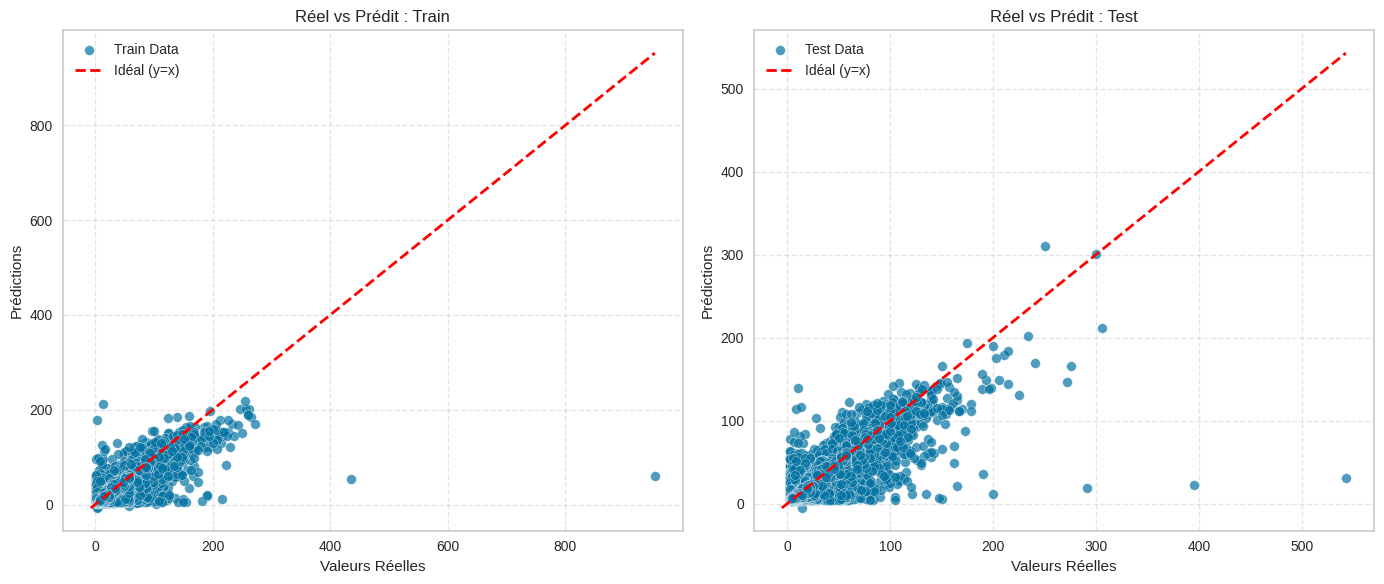

In [163]:
import numpy as np
import matplotlib.pyplot as plt

# Création de la figure avec 2 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Liste des jeux de données pour itérer facilement
datasets = [
    ("Train", np.array(y_train, dtype=float).flatten(), np.array(y_train_pred, dtype=float).flatten()),
    ("Test", np.array(y_test, dtype=float).flatten(), np.array(y_test_pred, dtype=float).flatten())
]

for ax, (name, y_true, y_pred) in zip(axes, datasets):
    # Nuage de points (Valeurs réelles vs Prédictions)
    ax.scatter(y_true, y_pred, alpha=0.7, edgecolors='w', label=f"{name} Data")
    
    # Ligne de référence idéale (y = x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Idéal (y=x)')
    
    # Personnalisation des axes et du titre
    ax.set_title(f"Réel vs Prédit : {name}")
    ax.set_xlabel("Valeurs Réelles")
    ax.set_ylabel("Prédictions")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

# Ajustement automatique des marges pour éviter les chevauchements
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


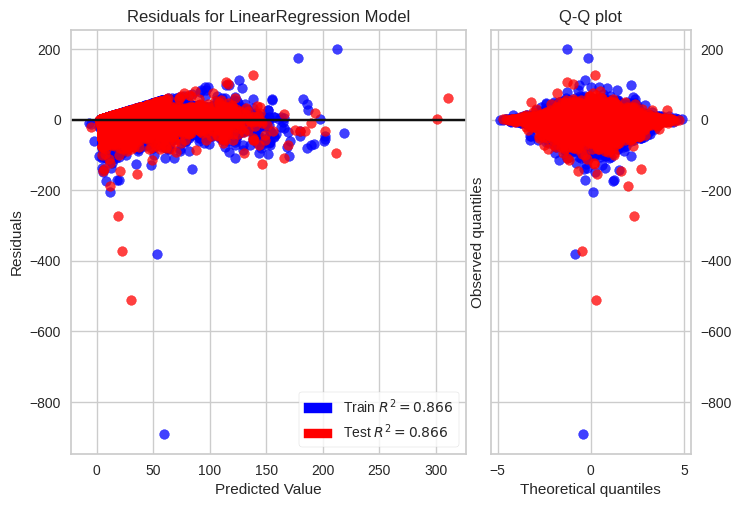

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [164]:
res_viz = ResidualsPlot(lr,
                        is_fitted="auto",
                        qqplot=True,
                        hist=False,
                        train_color="blue",
                        test_color="red",
                        force_model=True,
                       )
res_viz.fit(X_train, y_train)
res_viz.score(X_test, y_test)
res_viz.show()

### 6.5 Test de normalité des résidus (Anderson-Darling)

Le test d'Anderson-Darling évalue l'hypothèse H₀ : *les résidus suivent une loi normale*.  
Une p-value inférieure à 0.05 conduit à rejeter cette hypothèse.


In [71]:
# La moyenne des residus est:
reg_lin.resid.mean()

np.float64(2.176059704697774e-12)

#### Normalité


Une `p-value < alpha` (5%, en général) pour le test d'Anderson-Darling indique que l'hypothèse nulle de normalité de la distribution des résidus est rejetée.



In [72]:
# Normalite:
print("La p-value du test d'Aderson-Darling vaux", normal_ad(reg_lin.resid)[1])

La p-value du test d'Aderson-Darling vaux 0.0


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/_adnorm.py:72: RuntimeWarning: divide by zero encountered in log
  ad_values = (2 * i[sl1] - 1.0) / nobs * (np.log(z) + np.log1p(-z[sl2]))


---
## 🔴 Section 7 — Régression Ridge (Linéaire Régularisée)

### Pourquoi la régression Ridge ?

La **régression Ridge** (L2) est une extension de la régression linéaire qui ajoute un terme de pénalité proportionnel à la somme des carrés des coefficients.  
Elle est particulièrement utile pour :
- réduire le sur-apprentissage (*overfitting*)
- gérer la multicolinéarité

Nous l'intégrons dans un **Pipeline scikit-learn** avec normalisation préalable (`MinMaxScaler`) pour que la régularisation s'applique de manière équitable à toutes les variables.

### 7.1 Entraînement de base


## Ridge

In [172]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

# Pipeline : standardisation + Ridge avec alpha (lambda) = 0.5
pipeline_rg = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', Ridge(alpha=0.1, fit_intercept=False))
])

train_model2(pipeline_rg, X_train, y_train, X_test, y_test)

(array([ 6.31423594, 24.17102615,  7.06689193, ..., 11.17447796,
        10.33519774, 18.35298102], shape=(1342520,)),
 array([ 6.76143324,  6.83025629,  6.81584241, ..., 10.39673415,
        10.7366639 , 18.8482251 ], shape=(575367,)))

### 7.2 Évaluation du modèle Ridge


In [166]:
y_train_pred = result[0]
y_test_pred= result[1]

In [167]:
    mae_test = metrics.mean_absolute_error(y_test, y_test_pred)
    mape_test = metrics.mean_absolute_percentage_error(y_test, y_test_pred)
    rmse_test = metrics.root_mean_squared_error(y_test, y_test_pred)
    r2_test = metrics.r2_score(y_test, y_test_pred)

In [168]:
print(mae_test,mape_test,rmse_test,r2_test)

2.259697833383318 0.20096869772155537 4.042358089613555 0.865631524692703


In [169]:
# Check for Multicollinearity
# Variance Inflation Factor (VIF)
r_square_test = metrics.r2_score(y_test, pipeline_rg.predict(X_test))

vif = 1 / (1 - r_square_test)
vif

7.447813041497474

### 7.3 Optimisation des hyperparamètres (GridSearchCV)

Nous cherchons la combinaison optimale de :
- `alpha` (force de la régularisation)
- `fit_intercept` (avec ou sans constante)
- `scaler` (MinMaxScaler vs StandardScaler)

La recherche est effectuée par validation croisée à 5 folds, en optimisant la MAE négative.


In [174]:

param_grid = {
    'model__alpha': [0.01, 0.1, 0.5, 1, 5, 10],
    'model__fit_intercept': [True, False],
    'scaler': [MinMaxScaler(), StandardScaler()]
}

grid = GridSearchCV(
    estimator=pipeline_rg,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('model',
                                        Ridge(alpha=0.1,
                                              fit_intercept=False))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.01, 0.1, 0.5, 1, 5, 10],
                         'model__fit_intercept': [True, False],
                         'scaler': [MinMaxScaler(), StandardScaler()]},
             scoring='neg_mean_absolute_error', verbose=2)

In [175]:
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV :", -grid.best_score_)

Meilleurs paramètres : {'model__alpha': 0.01, 'model__fit_intercept': True, 'scaler': StandardScaler()}
Meilleur score CV : 2.259205537005584


---
## 🔁 Section 8 — Validation Croisée (Cross-Validation)

La **validation croisée à k-folds** (ici k=5) permet d'obtenir une estimation plus robuste et moins biaisée des performances du modèle, en évaluant celui-ci sur 5 sous-ensembles différents des données d'entraînement.

Nous utilisons `cross_validate` de scikit-learn qui permet d'évaluer simultanément plusieurs métriques.

**Métriques évaluées :**
- `neg_mean_absolute_error` — MAE (signe négatif par convention scikit-learn)
- `r2` — Coefficient de détermination

Nous comparons les scores sur le train et le test à chaque fold pour détecter un éventuel overfitting.


## Cross Validation

In [78]:
from sklearn.model_selection import cross_val_score, cross_validate, cross_val_predict, GridSearchCV

In [170]:
# Pour lister les noms des métriques à fournir à scoring, vous pouvez consulter le site de sklearn ou
# éxecuter dans une cellule de code: sklearn.metrics.SCORERS.
# Avec cross_validation, il est possible d'optimiser le modèle avec plusieurs métriques d'évaluation.

scores = cross_validate(lr, X_train, y_train,
                        cv=5,
                        scoring=["neg_mean_absolute_error",'r2'],  # ["r2", "neg_root_mean_squared_error"]
                        return_train_score=True,
                        verbose=True,
                       )
scores

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    5.0s finished


{'fit_time': array([0.88536143, 0.85148716, 0.84770155, 0.91728926, 0.8315897 ]),
 'score_time': array([0.04038668, 0.02924657, 0.02681947, 0.02739954, 0.03323221]),
 'test_neg_mean_absolute_error': array([-2.25525588, -2.26611434, -2.26670995, -2.2567788 , -2.25867518]),
 'train_neg_mean_absolute_error': array([-2.26193676, -2.25996201, -2.25913036, -2.26215334, -2.25970639]),
 'test_r2': array([0.87170423, 0.84641393, 0.86828558, 0.87203874, 0.87046548]),
 'train_r2': array([0.86418427, 0.8706738 , 0.86499468, 0.86409946, 0.86448182])}

In [95]:
metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

In [81]:
pd.DataFrame(scores)

,fit_time,score_time,test_neg_mean_absolute_error,train_neg_mean_absolute_error,test_r2,train_r2
0,0.799202,0.040076,-2.344999,-2.339060,0.815381,0.844264
1,0.803745,0.025539,-2.349043,-2.338831,0.841086,0.837637
2,0.807286,0.028049,-2.336037,-2.342420,0.846090,0.836416
3,0.794442,0.027840,-2.345519,-2.338744,0.837358,0.838582
4,0.782828,0.025821,-2.328087,-2.343384,0.851823,0.835029


In [97]:
cross_val_score(lr, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")

array([-2.06787769, -2.06982568, -2.06832362, -2.06947678, -2.06488973])

---
## 📊 Section 9 — Importance des variables (Régression Linéaire)

Les **coefficients** de la régression linéaire représentent l'impact marginal de chaque variable sur la prédiction du tarif (en USD, toutes choses égales par ailleurs).

Un coefficient positif signifie que l'augmentation de la variable augmente le tarif prédit, et inversement pour un coefficient négatif. L'importance relative est mesurée par la valeur absolue du coefficient.

> ⚠️ Cette interprétation est valide uniquement si les variables ont été normalisées ou si elles sont sur des échelles comparables.


## Importance des variables

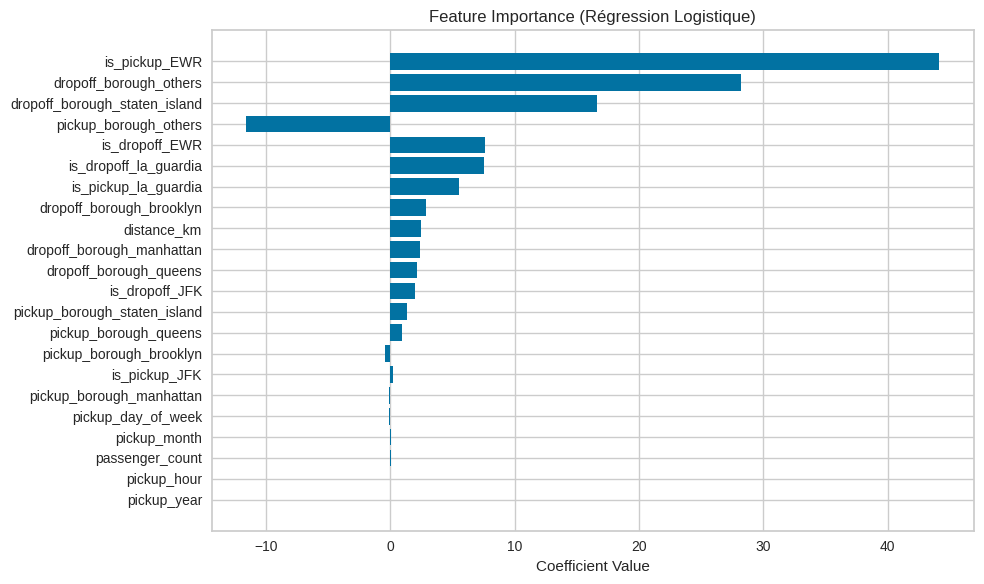

In [171]:
import matplotlib.pyplot as plt
import pandas as pd
 
# Récupérer les coefficients et les noms des features
importance = pd.DataFrame({'Feature': lr.feature_names_in_, 'Coefficient': lr.coef_[0]})
importance = importance.sort_values('Coefficient', key=abs, ascending=True)
 
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Régression Logistique)')
plt.tight_layout()
plt.show()


---
## 🌳 Section 10 — Arbre de Décision (Decision Tree Regressor)

L'**arbre de décision** est un modèle non linéaire qui partitionne récursivement l'espace des features selon des seuils optimaux.  
Ses avantages :
- Interprétabilité visuelle (arbre lisible)
- Capture des relations non linéaires
- Peu ou pas de preparation de donnees

### 10.1 Entraînement du modèle de base (sans contraintes)

Nous entraînons d'abord un arbre sans restriction pour établir une performance de référence (souvent en sur-apprentissage).


# Non linear models

## Decision tree

In [83]:
from sklearn.tree import DecisionTreeRegressor

In [176]:
# decision_pipe = Pipeline(steps=[("scaler", MinMaxScaler()),
#                            ("regressor", DecisionTreeRegressor(random_state=SEED)),
#                           ]
#                    )



tree=DecisionTreeRegressor(random_state=42).fit(X_train,y_train)


y_pred_decision_baseline = tree.predict(X_test)

decision_baseline_mape = metrics.mean_absolute_percentage_error(y_test, y_pred_decision_baseline)
print(f'Baseline MAPE: {decision_baseline_mape * 100:.2f}%')


Baseline MAPE: 26.35%


In [ ]:
#Optimisation

### 10.2 Optimisation des hyperparamètres (GridSearchCV)

Pour contrôler la profondeur de l'arbre et éviter le sur-apprentissage, nous optimisons :
- `max_depth` — profondeur maximale de l'arbre
- `min_samples_split` — nombre minimum d'échantillons pour diviser un nœud
- `min_samples_leaf` — nombre minimum d'échantillons dans une feuille terminale


In [177]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

decision_param_grid = {
    'max_depth': [5, 10],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [ 5, 10]

}

decision_grid_search = GridSearchCV(
    estimator=tree,
    param_grid=decision_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

decision_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'min_samples_leaf': [5, 10],
                         'min_samples_split': [2, 10, 20]},
             scoring='neg_mean_absolute_error')

In [178]:
print("Meilleurs paramètres :", decision_grid_search.best_params_)
print("Meilleur score CV :", -decision_grid_search.best_score_)

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Meilleur score CV : 2.0774425879944793


In [179]:
y_pred_decision_optimized = decision_grid_search.best_estimator_.predict(X_test)

decision_optimized_mae = metrics.mean_absolute_error(y_test, y_pred_decision_optimized)

print(f'Optimized MAE: {decision_optimized_mae:.4f}')

Optimized MAE: 2.0772


### 10.3 Visualisation de l'arbre de décision optimisé

Nous générons une représentation graphique de l'arbre optimisé pour en comprendre les règles de décision.  
Cette visualisation est particulièrement utile pour l'interprétabilité et la présentation du modèle.


In [67]:
!apt-get install -y graphviz
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 90 not upgraded.


In [180]:
from sklearn.tree import export_graphviz
import graphviz

model = decision_grid_search.best_estimator_

dot_data = export_graphviz(
    model,
    feature_names=list(X_train.columns),
    filled=True,
    rounded=True,
    special_characters=True,
    impurity=True,
    precision=2
)

graph = graphviz.Source(dot_data)
graph.render("decision_tree", format="png", cleanup=True)
graph

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.215265 to fit


---
## ⚡ Section 11 — LightGBM (Gradient Boosting)

**LightGBM** (Light Gradient Boosting Machine) est un algorithme d'ensemble basé sur le *gradient boosting* de type `GBDT` (Gradient Boosted Decision Trees).  

Ses avantages par rapport aux autres algorithmes de boosting :
- Très rapide (entraînement sur grandes données)
- Faible consommation mémoire
- Gère nativement les variables catégorielles
- Généralement plus performant que les modèles linéaires sur des données complexes

### 11.1 Entraînement du modèle de base


## LgbM

In [181]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 341
[LightGBM] [Info] Number of data points in the train set: 1342520, number of used features: 22
[LightGBM] [Info] Start training from score 12.916173


LGBMRegressor(learning_rate=0.05, n_estimators=300)

In [182]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 2.0297160739990208
RMSE : 3.8469679564368024


### 11.2 Optimisation des hyperparamètres (GridSearchCV)

Nous optimisons les hyperparamètres clés de LightGBM :
- `n_estimators` — nombre d'arbres dans l'ensemble
- `learning_rate` — taux d'apprentissage (trade-off vitesse / précision)
- `num_leaves` — complexité des arbres individuels


In [183]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = LGBMRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 63]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Best params:", grid.best_params_)
print("MAE:", mae)
print("RMSE:", rmse)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END model__alpha=0.01, model__fit_intercept=True, scaler=MinMaxScaler(); total time=   2.3s
[CV] END model__alpha=0.01, model__fit_intercept=True, scaler=StandardScaler(); total time=   1.5s
[CV] END model__alpha=0.01, model__fit_intercept=False, scaler=MinMaxScaler(); total time=   1.2s
[CV] END model__alpha=0.01, model__fit_intercept=False, scaler=MinMaxScaler(); total time=   1.1s
[CV] END model__alpha=0.01, model__fit_intercept=False, scaler=StandardScaler(); total time=   1.4s
[CV] END model__alpha=0.1, model__fit_intercept=True, scaler=MinMaxScaler(); total time=   1.3s
[CV] END model__alpha=0.1, model__fit_intercept=True, scaler=MinMaxScaler(); total time=   1.3s
[CV] END model__alpha=0.1, model__fit_intercept=True, scaler=StandardScaler(); total time=   1.5s
[CV] END model__alpha=0.1, model__fit_intercept=False, scaler=MinMaxScaler(); total time=   1.1s
[CV] END model__alpha=0.1, model__fit_intercept=False, scaler

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__alpha=0.01, model__fit_intercept=True, scaler=MinMaxScaler(); total time=   2.2s
[CV] END model__alpha=0.01, model__fit_intercept=True, scaler=MinMaxScaler(); total time=   1.3s
[CV] END model__alpha=0.01, model__fit_intercept=True, scaler=StandardScaler(); total time=   1.5s
[CV] END model__alpha=0.01, model__fit_intercept=False, scaler=MinMaxScaler(); total time=   1.2s
[CV] END model__alpha=0.01, model__fit_intercept=False, scaler=StandardScaler(); total time=   1.4s
[CV] END model__alpha=0.1, model__fit_intercept=True, scaler=MinMaxScaler(); total time=   1.2s
[CV] END model__alpha=0.1, model__fit_intercept=True, scaler=StandardScaler(); total time=   1.5s
[CV] END model__alpha=0.1, model__fit_intercept=False, scaler=MinMaxScaler(); total time=   1.2s
[CV] END model__alpha=0.1, model__fit_intercept=False, scaler=MinMaxScaler(); total time=   1.2s
[CV] END model__alpha=0.1, model__fit_intercept=False, scaler=StandardScaler(); total time=   1.4s
[CV] END model__alpha=

---
## 💾 Section 12 — Sauvegarde des modèles

Nous sérialisons les meilleurs modèles entraînés (après optimisation des hyperparamètres) avec **joblib**.  
Ces fichiers `.pkl` peuvent être rechargés ultérieurement pour générer des prédictions sans réentraîner les modèles.

### Modèles sauvegardés

| Fichier | Modèle |
|---------|--------|
| `lgbm_model2.pkl` | LightGBM optimisé (meilleur estimateur GridSearchCV) |
| `tree_model2.pkl` | Arbre de décision optimisé (meilleur estimateur GridSearchCV) |


In [187]:
import joblib
 
joblib.dump(best_model, "lgbm_model2.pkl")

['lgbm_model2.pkl']

In [168]:
decision_grid_search.best_estimator_

DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=42)

In [186]:
import joblib

joblib.dump(decision_grid_search.best_estimator_, "tree_model2.pkl")

['tree_model2.pkl']